<a href="https://colab.research.google.com/github/willvw/DataSci101/blob/HW5/Copy_of_hw6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 6

The National Health and Nutrition Examination Survey (NHANES) is a
cross sectional observational study run every 2-3 years by the
United States Centers for Disease Control (CDC).  It collects
extensive demographic and health-related data on a representative
sample of the US population. We will work with a subset of the possible measures that the NHANES survey collects on basic biometric features.


First we import the libraries that we will be using.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

Now we load the NHANES data from a file.


In [2]:
url = "https://raw.githubusercontent.com/UM-Data-Science-101/homework-06/main/nhanes.csv.gz"
df = pd.read_csv(url, compression='gzip')

Many biological processes behave differently during development
compared to in adulthood.  For this analysis, we will focus on
people of age 18 or greater (RIDAGEYR contains each subject's age in
years).

In [3]:
df = df.loc[df["RIDAGEYR"] >= 18]

We want to great the gender variable as categorical, so we just indicate that here:

In [4]:
df["RIAGENDR"] = df["RIAGENDR"].replace([1.0, 2.0], ["Male","Female"]).astype("category")

Here are the columns from this data set:

In [5]:
df.columns

Index(['SEQN', 'RIDAGEYR', 'RIAGENDR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BPXSY1',
       'BPXSY2', 'BPXSY3'],
      dtype='object')

## Question 1

### Question 1.1

The `BPXSY1`, `BPXSY2`, and `BXSPY3` columns in the data are repeated systolic blood pressure measurements (the "120" in when your doctor says your blood pressure is "120/80"). Numbers higher than 120 indicate various degrees of "hypertension" (i.e., high blood pressure).

Create a new column `BPXSY`  in the `df` table that is mean of the three measurements for each person (i.e., add the three values together and divide by 3 for each person).


In [6]:
df['BPXSY'] = df[['BPXSY1', 'BPXSY2', 'BPXSY3']].mean(axis=1)

Plot the marginal distribution of this measurement.

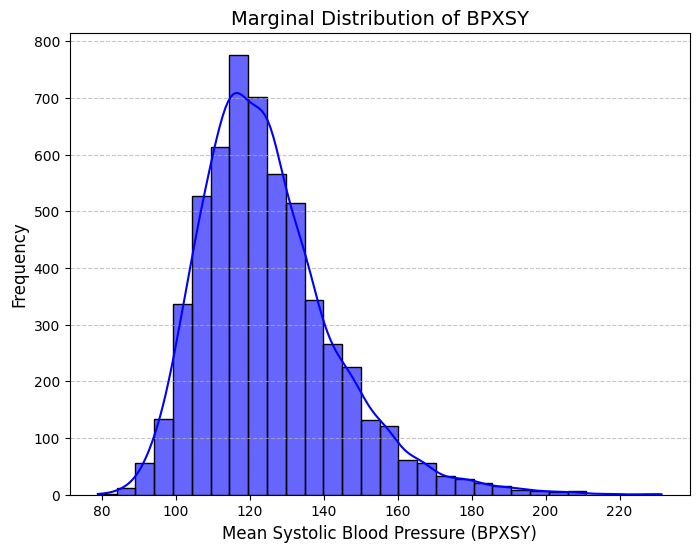

In [7]:
plt.figure(figsize=(8, 6))
sb.histplot(df['BPXSY'], kde=True, color='blue', bins=30, alpha=0.6)
plt.title('Marginal Distribution of BPXSY', fontsize=14)
plt.xlabel('Mean Systolic Blood Pressure (BPXSY)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Comment on the **location**, **spread**, and **skew** in this plot. You only need to give broad descriptions (what is a typical value? where are most of the values? is there any skew?).


Your Answer: The distribution appears to be centered around 120 with a unimodal and normal shapre, with a slight right tail. Values range from anywhere 80 to >220.


### Question 1.2

Create a plot that shows two boxplots that show the **conditional distribution** of `BPXSY` for the two genders ("MALE" and "FEMALE") in the `RIAGENDR` column.

<ipython-input-9-83ab5b97b4e9>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df, x='RIAGENDR', y='BPXSY', palette='Set1')


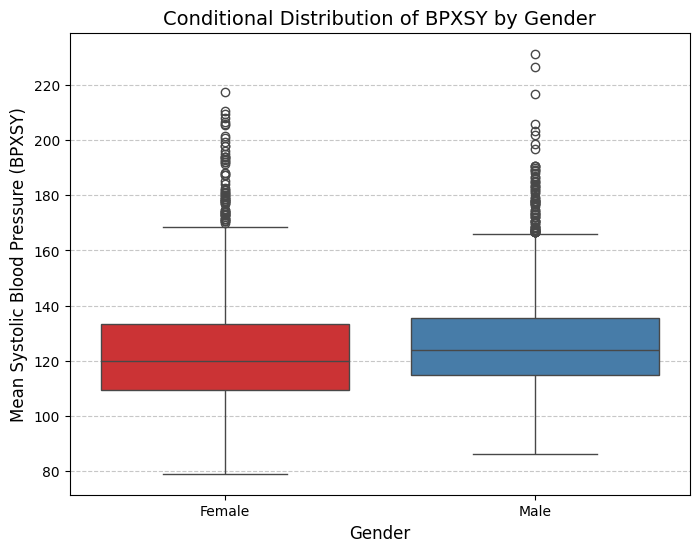

In [9]:
plt.figure(figsize=(8, 6))
sb.boxplot(data=df, x='RIAGENDR', y='BPXSY', palette='Set1')
plt.title('Conditional Distribution of BPXSY by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Mean Systolic Blood Pressure (BPXSY)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on this plot, would you say there is much of a difference between men and women on BPXSY? Justify your answer based on both location and spread observed in the plot.


Your Answer: There is a slight difference between men and women in terms of systolic blood pressure, but it is not substantial enough. The median BPXSY for males appears slightly higher than that for females, as indicated by the central line in each boxplot. This suggests that, on average, men tend to have slightly higher systolic blood pressure compared to women. But this difference, in the grand scheme of things, is not that great.



### Question 1.3

Calculate the **effect size** of the difference between men and women on BPSXY. As a reminder, you will need to compute the **pooled standard deviation**:

$$S_p = \sqrt{\frac{n_1 S_1^2 + n_2 S_2^2}{n_1 + n_1}}$$

where $S_g^2$ is the variance of group $g$ and $n_g$ is the size of group $g$.

Please note: the class notes suggest using `df.groupby("GROUP").size()` to get the number of units in each group. Because of missing data issues, it turns out this is bad advice. A better strategy is focus on the variable of interest `x = df.groupby("GROUP")["VAR"]` and the `x.count()` to get the size of each group.

In [12]:
grouped = df.groupby("RIAGENDR")["BPXSY"]

#means and standard deviations for each group
mean_male = grouped.mean()["Male"]
mean_female = grouped.mean()["Female"]
std_male = grouped.std()["Male"]
std_female = grouped.std()["Female"]
n_male = grouped.count()["Male"]
n_female = grouped.count()["Female"]

#pooled standard deviation
pooled_std = np.sqrt(((n_male - 1) * std_male**2 + (n_female - 1) * std_female**2) / (n_male + n_female - 2))

#cohen's d
cohens_d = (mean_male - mean_female) / pooled_std

print(f"Cohen's d: {cohens_d}")

Cohen's d: 0.19354235677268705


<ipython-input-12-b7508081f117>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("RIAGENDR")["BPXSY"]


Based on the following lists of effect sizes, how would you categorize the difference in BP between men and women?

Effect size magnitude (ignore +/-)
* Very small: 0 - 0.01
* Small: 0.1 - 0.20
* Medium: 0.2 - 	0.50
* Large: 0.5 - 	0.80
* Very large: 0.8 -	1.20
* Huge: 1.2 - 	2.0+


Your Answer: Based on the effect size of 0.1935, we can see the resulting effect is small. In other words, the effect of gender on BP between men and women is relatively small.



## Question 2

Let's investigate the relationship between body-mass-index (BMI) and blood pressure.

### Question 2.1

Make a `regplot` of these two measurements with "BMXBMI" on the x-axis. The `marker = '.'` option makes the plot a little cleaner and the `line_kws = {"color": "orange"}` makes the line easier to see.

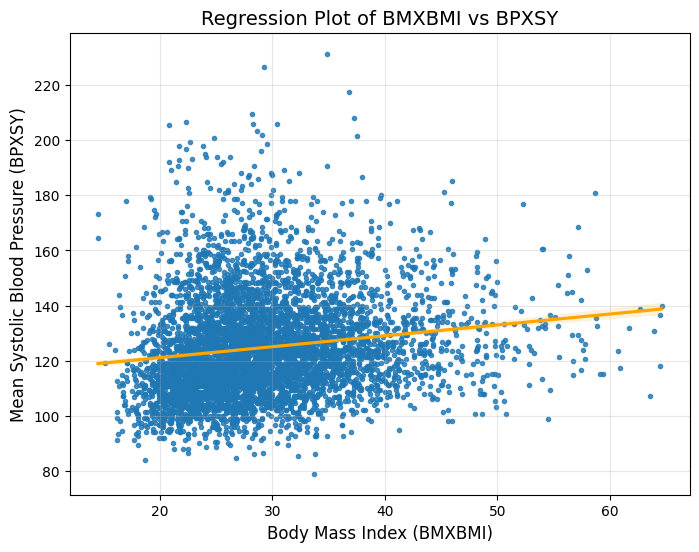

In [13]:
df['BPXSY'] = df[['BPXSY1', 'BPXSY2', 'BPXSY3']].mean(axis=1)

# Create a regression plot for BMXBMI vs BPXSY
plt.figure(figsize=(8, 6))
sb.regplot(data=df, x='BMXBMI', y='BPXSY', marker='.', line_kws={"color": "orange"})
plt.title('Regression Plot of BMXBMI vs BPXSY', fontsize=14)
plt.xlabel('Body Mass Index (BMXBMI)', fontsize=12)
plt.ylabel('Mean Systolic Blood Pressure (BPXSY)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Given what you see in this plot, how would you categorize the **direction** of the relationship between these variables?



Your Answer: The direction of the relationship between these variables is positive. As BMI increases, systolic blood pressure tends to increase slightly as well, as shown by the upward slope of the regression line. However, the relationship appears to be weak.



### Question 2.2

To get a better understanding of the relationship for these data compute **Z-scores** for both BMI and BP. Plot them again using a scatter plot (`marker = '.'`), also add vertical and horizontal lines at 0 using

```
plt.axhline(0, color = "black")
plt.axvline(0, color = "black")
```

<ipython-input-21-e68394a2d02d>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Z_BMXBMI'] = zscore(df_clean['BMXBMI'])
<ipython-input-21-e68394a2d02d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Z_BPXSY'] = zscore(df_clean['BPXSY'])


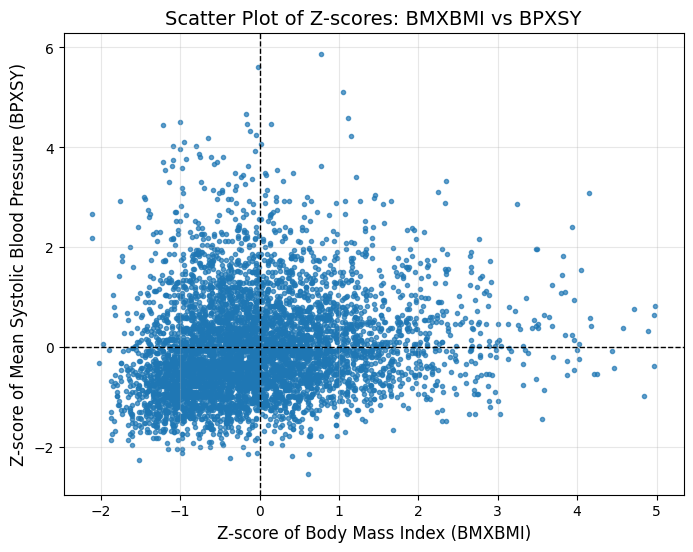

In [21]:
df['BPXSY'] = df[['BPXSY1', 'BPXSY2', 'BPXSY3']].mean(axis=1)
df_clean = df.dropna(subset=['BMXBMI', 'BPXSY'])

from scipy.stats import zscore
df_clean['Z_BMXBMI'] = zscore(df_clean['BMXBMI'])
df_clean['Z_BPXSY'] = zscore(df_clean['BPXSY'])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_clean['Z_BMXBMI'], df_clean['Z_BPXSY'], marker='.', alpha=0.7)
plt.axhline(0, color="black", linestyle='--', linewidth=1)  # Horizontal line at 0
plt.axvline(0, color="black", linestyle='--', linewidth=1)  # Vertical line at 0
plt.title('Scatter Plot of Z-scores: BMXBMI vs BPXSY', fontsize=14)
plt.xlabel('Z-score of Body Mass Index (BMXBMI)', fontsize=12)
plt.ylabel('Z-score of Mean Systolic Blood Pressure (BPXSY)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Based on the number of observations in each quadrant, would you say that that more points are in the upper-left and lower-right or in the upper-left and lower-right quadrants?


Your Answer: The density of points appears higher in the upper-right and lower-left quadrants compared to the upper-left and lower-right quadrants. This points to the notion that individuals with above-average BMI tend to also have above-average systolic blood pressure, and those with below-average BMI tend to have below-average systolic blood pressure.


### Question 2.3

Calculate the Pearson correlation/correlation coefficient for these two measures. You can use a built in method for DataFrames.

In [22]:
correlation = df_clean['BMXBMI'].corr(df_clean['BPXSY'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

Pearson Correlation Coefficient: 0.1539


What does this value tell us? Is is consistent with the graphs in the previous two part? Why or why not?



Your Answer: The Pearson correlation coefficient of 0.1539 indicates a weak positive relationship BMXBMI and BPXSY. The scatter plot of Z-scores shows a dense cloud of points with a slight upward shape, consistent with the weak positive correlation.



### Question 2.4

We have observed that both BMI and blood pressure exhibit some right skew. Transform both using reciprocal, square root, and log;  and the compute the correlation matrix for  all combinations of both. For the strongest linear relationship, plot the two transformations and compute the correlation.

<ipython-input-23-a7f201f494b5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['BMI_reciprocal'] = 1 / df_clean['BMXBMI']
<ipython-input-23-a7f201f494b5>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['BMI_sqrt'] = np.sqrt(df_clean['BMXBMI'])
<ipython-input-23-a7f201f494b5>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.or

Correlation Matrix:
                BMI_reciprocal  BMI_sqrt   BMI_log  BP_reciprocal   BP_sqrt  \
BMI_reciprocal        1.000000 -0.972105 -0.987845       0.199170 -0.177419   
BMI_sqrt             -0.972105  1.000000  0.996676      -0.187166  0.167179   
BMI_log              -0.987845  0.996676  1.000000      -0.192428  0.171717   
BP_reciprocal         0.199170 -0.187166 -0.192428       1.000000 -0.988284   
BP_sqrt              -0.177419  0.167179  0.171717      -0.988284  1.000000   
BP_log               -0.185398  0.174549  0.179341      -0.994907  0.998622   

                  BP_log  
BMI_reciprocal -0.185398  
BMI_sqrt        0.174549  
BMI_log         0.179341  
BP_reciprocal  -0.994907  
BP_sqrt         0.998622  
BP_log          1.000000  
Strongest linear relationship: ('BP_log', 'BP_sqrt') with correlation 0.9986


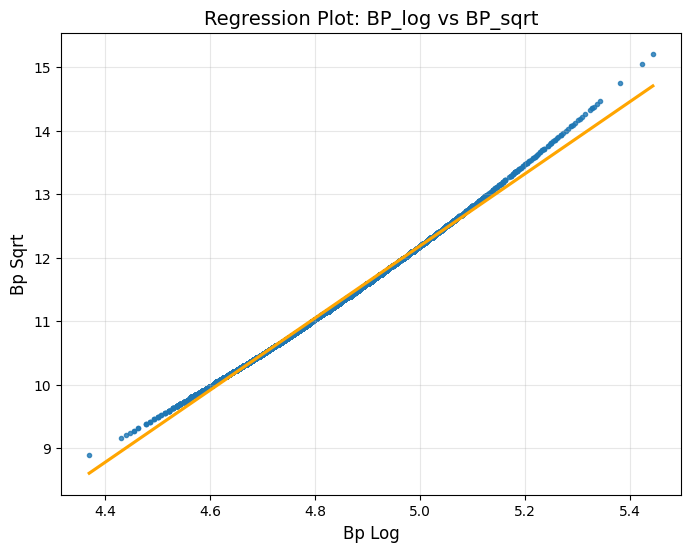

In [23]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

df_clean = df.dropna(subset=['BMXBMI', 'BPXSY'])

df_clean['BMI_reciprocal'] = 1 / df_clean['BMXBMI']
df_clean['BMI_sqrt'] = np.sqrt(df_clean['BMXBMI'])
df_clean['BMI_log'] = np.log(df_clean['BMXBMI'])

df_clean['BP_reciprocal'] = 1 / df_clean['BPXSY']
df_clean['BP_sqrt'] = np.sqrt(df_clean['BPXSY'])
df_clean['BP_log'] = np.log(df_clean['BPXSY'])

correlation_matrix = df_clean[['BMI_reciprocal', 'BMI_sqrt', 'BMI_log',
                                'BP_reciprocal', 'BP_sqrt', 'BP_log']].corr()
print("Correlation Matrix:")
print(correlation_matrix)

strongest_correlation = correlation_matrix.unstack().abs().sort_values(ascending=False)
strongest_pair = strongest_correlation[strongest_correlation < 1].idxmax()
print(f"Strongest linear relationship: {strongest_pair} with correlation {strongest_correlation[strongest_pair]:.4f}")

x_var, y_var = strongest_pair
plt.figure(figsize=(8, 6))
sb.regplot(data=df_clean, x=x_var, y=y_var, marker='.', line_kws={"color": "orange"})
plt.title(f'Regression Plot: {x_var} vs {y_var}', fontsize=14)
plt.xlabel(x_var.replace('_', ' ').title(), fontsize=12)
plt.ylabel(y_var.replace('_', ' ').title(), fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## Question 3

### Question 3.1

Compute and save into a variable the correlation of `BMXBMI` and `BPXSY`.

Compute and save into variables the means and standard deviations of these variables.

Using these values compute the slope and intercept of the regression line that relates blood pressure and BMI. For this analysis, consider BMI as the "X" variable (sometimes called the independent variable) and blood pressure as the "Y" variable (sometimes called the dependent variable).

In [24]:
correlation = df_clean['BMXBMI'].corr(df_clean['BPXSY'])

mean_bmi = df_clean['BMXBMI'].mean()
std_bmi = df_clean['BMXBMI'].std()
mean_bp = df_clean['BPXSY'].mean()
std_bp = df_clean['BPXSY'].std()

slope = correlation * (std_bp / std_bmi)
intercept = mean_bp - (slope * mean_bmi)

print(f"Correlation: {correlation:.4f}")
print(f"Mean BMI: {mean_bmi:.4f}")
print(f"Std BMI: {std_bmi:.4f}")
print(f"Mean BP: {mean_bp:.4f}")
print(f"Std BP: {std_bp:.4f}")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

Correlation: 0.1539
Mean BMI: 29.4067
Std BMI: 7.0589
Mean BP: 124.8270
Std BP: 18.1335
Slope: 0.3953
Intercept: 113.2033


### Question 3.2

Using the slope and intercept from the previous part, compute the following:

- The average blood pressure for people with a BMI of 20.
- The average blood pressure for people with a BMI of 30.
- The difference in average blood pressures for people with BMI values of 18 and BMI values of 21.

In [25]:
slope = 0.39527494027248694
intercept = 113.2032645764818

#average blood pressure for BMI of 20
bmi_20_bp = slope * 20 + intercept
print(f"Average BP for BMI of 20: {bmi_20_bp:.4f}")

#average blood pressure for BMI of 30
bmi_30_bp = slope * 30 + intercept
print(f"Average BP for BMI of 30: {bmi_30_bp:.4f}")

#average blood pressure for BMI of 18 and BMI of 21
bmi_18_bp = slope * 18 + intercept
bmi_21_bp = slope * 21 + intercept

#the difference in average blood pressures
difference_bp = bmi_21_bp - bmi_18_bp
print(f"BP difference between BMI 21 and 18: {difference_bp:.4f}")

Average BP for BMI of 20: 121.1088
Average BP for BMI of 30: 125.0615
BP difference between BMI 21 and 18: 1.1858


### Question 3.3

Create a scatter plot of the data with the regression line overlayed. Do not use the `regplot` or `lmplot` functions. You may use `plt.axline` to add the regression line.


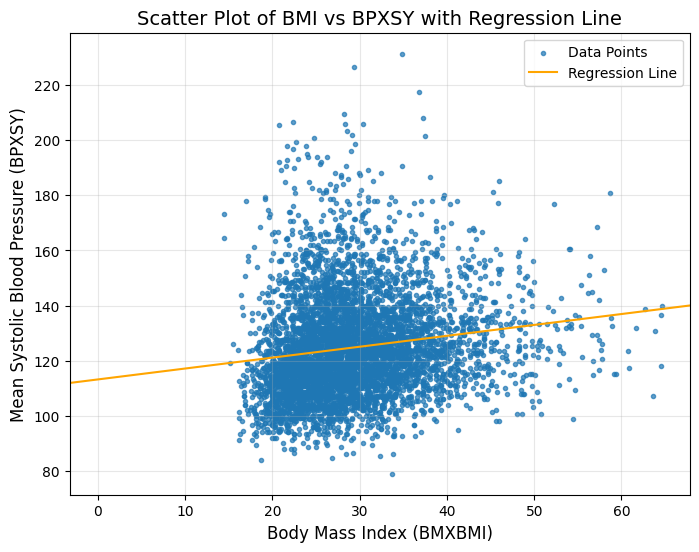

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['BMXBMI'], df_clean['BPXSY'], marker='.', alpha=0.7, label='Data Points')
plt.axline((0, intercept), slope=slope, color='orange', label='Regression Line')
plt.title('Scatter Plot of BMI vs BPXSY with Regression Line', fontsize=14)
plt.xlabel('Body Mass Index (BMXBMI)', fontsize=12)
plt.ylabel('Mean Systolic Blood Pressure (BPXSY)', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Question 3.4

Use the `statsmodels` library to fit a linear regression model to the data using the `sm.OLS` function. Print the summary of the model and verify that your calculations from the previous parts are correct.

In [27]:
import statsmodels.api as sm

X = sm.add_constant(df_clean['BMXBMI'])
y = df_clean['BPXSY']

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

intercept_ols = results.params['const']
slope_ols = results.params['BMXBMI']
print(f"Slope (OLS): {slope_ols:.4f}")
print(f"Intercept (OLS): {intercept_ols:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  BPXSY   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     133.7
Date:                Thu, 27 Feb 2025   Prob (F-statistic):           1.45e-30
Time:                        22:01:40   Log-Likelihood:                -23736.
No. Observations:                5514   AIC:                         4.748e+04
Df Residuals:                    5512   BIC:                         4.749e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        113.2033      1.034    109.487      0.0